In [3]:
import sys
import numpy as np
import time
import subprocess
import os

# --- 1. Generowanie zestawów danych w locie ---
def generate_datasets():
    print("Generowanie zbiorów danych...")
    # Zbiór A: Ekstremalnie rzadki okrąg (10000 punktów)
    t = np.linspace(0, 2*np.pi, 10000, endpoint=False)
    circle_sparse = np.column_stack((np.cos(t), np.sin(t)))
    np.savetxt("sparse_circle.csv", circle_sparse, delimiter=",")
    
    # Zbiór B: Gęsty Torus (50 punktów)
    theta = np.random.uniform(0, 2*np.pi, 50)
    phi = np.random.uniform(0, 2*np.pi, 50)
    R, r = 2, 1
    x = (R + r * np.cos(theta)) * np.cos(phi)
    y = (R + r * np.cos(theta)) * np.sin(phi)
    z = r * np.sin(theta)
    torus_dense = np.column_stack((x, y, z))
    np.savetxt("dense_torus50.csv", torus_dense, delimiter=",")

# --- 2. Tworzenie izolowanego workera dla Dionysusa ---
WORKER_SCRIPT = "dionysus_memory_worker.py"
with open(WORKER_SCRIPT, "w") as f:
    f.write("""
import sys
import dionysus as d
import numpy as np
import resource

task = sys.argv[1]
file_path = sys.argv[2]
max_dim = int(sys.argv[3])
max_eps = float(sys.argv[4])

# Wczytanie punktów i budowa kompleksu
points = np.loadtxt(file_path, delimiter=",")
f = d.fill_rips(points, max_dim + 1, max_eps)

# Wykonanie zadania
if task == "homology":
    d.homology_persistence(f)
elif task == "cohomology":
    # Flaga False, aby mierzyć czysty algorytm bez narzutu na archiwizację!
    d.cohomology_persistence(f, prime=2, keep_cocycles=False)
elif task == "complex":
    pass # Tylko mierzymy budowę

# Zrzut twardego RAM-u z systemu (w Megabajtach)
usage = resource.getrusage(resource.RUSAGE_SELF)
print(usage.ru_maxrss / 1024.0)
""")

# --- 3. Logika uruchamiająca pomiary ---
def run_worker(task, file_path, max_dim, max_eps):
    cmd = [sys.executable, WORKER_SCRIPT, task, file_path, str(max_dim), str(max_eps)]
    start_time = time.time()
    result = subprocess.run(cmd, capture_output=True, text=True)
    exec_time = time.time() - start_time
    
    try:
        peak_mem_mb = float(result.stdout.strip())
    except ValueError:
        peak_mem_mb = 0.0
    return exec_time, peak_mem_mb

def run_benchmark(name, file_path, max_dim, max_eps):
    print(f"\n{'='*40}")
    print(f"BENCHMARK: {name}")
    print(f"Parametry: dim={max_dim}, eps={max_eps}")
    print(f"{'='*40}")
    
    # Krok 1: Zmierzenie samego kompleksu (Tło)
    t_comp, m_comp = run_worker("complex", file_path, max_dim, max_eps)
    print(f"[BAZA] Budowa jawnego kompleksu: {m_comp:.2f} MB")
    
    # Krok 2: Homologia (Odejmujemy bazę, żeby mieć czysty narzut)
    t_hom_tot, m_hom_tot = run_worker("homology", file_path, max_dim, max_eps)
    t_hom = t_hom_tot #max(0.0, t_hom_tot - t_comp)
    m_hom = m_hom_tot #max(0.0, m_hom_tot - m_comp)
    
    # Krok 3: Kohomologia (Odejmujemy bazę)
    t_coh_tot, m_coh_tot = run_worker("cohomology", file_path, max_dim, max_eps)
    t_coh = t_coh_tot #max(0.0, t_coh_tot - t_comp)
    m_coh = m_coh_tot #max(0.0, m_coh_tot - m_comp)
    
    print(f"\n--- WYNIKI (Czysty narzut algorytmiczny) ---")
    print(f"Homologia:   Czas = {t_hom:.4f} s | RAM (Fill-in) = {m_hom:.2f} MB")
    print(f"Kohomologia: Czas = {t_coh:.4f} s | RAM (Fill-in) = {m_coh:.2f} MB")
    
    if m_coh > m_hom:
        print(f"-> Kohomologia zużyła {m_coh/max(0.1, m_hom):.1f}x WIĘCEJ pamięci!")
    else:
        print(f"-> Kohomologia zużyła {m_hom/max(0.1, m_coh):.1f}x MNIEJ pamięci!")

# --- 4. Wykonanie testów ---
generate_datasets()

# TEST 1: Ekstremalnie rzadki graf cyklu. Malutki epsilon = brak gęstniejących struktur.
run_benchmark("Zbiór A (Turbo Rzadki - Okrąg 10000 pkt)", "sparse_circle.csv", max_dim=1, max_eps=0.1)

# TEST 2: Bardzo gęsta, zwarta chmura Ripsa. Duży epsilon = eksplozja sympleksów i fill-in.
run_benchmark("Zbiór B (Gęsty - Torus 50 pkt)", "dense_torus50.csv", max_dim=2, max_eps=2.5)

# Sprzątanie
if os.path.exists(WORKER_SCRIPT): os.remove(WORKER_SCRIPT)

Generowanie zbiorów danych...

BENCHMARK: Zbiór A (Turbo Rzadki - Okrąg 1000 pkt)
Parametry: dim=1, eps=0.1
[BAZA] Budowa jawnego kompleksu: 0.00 MB

--- WYNIKI (Czysty narzut algorytmiczny) ---
Homologia:   Czas = 210.3315 s | RAM (Fill-in) = 0.00 MB
Kohomologia: Czas = 207.1092 s | RAM (Fill-in) = 0.00 MB
-> Kohomologia zużyła 0.0x MNIEJ pamięci!

BENCHMARK: Zbiór B (Gęsty - Torus 50 pkt)
Parametry: dim=2, eps=2.5
[BAZA] Budowa jawnego kompleksu: 88.34 MB

--- WYNIKI (Czysty narzut algorytmiczny) ---
Homologia:   Czas = 0.3392 s | RAM (Fill-in) = 88.34 MB
Kohomologia: Czas = 0.2223 s | RAM (Fill-in) = 88.34 MB
-> Kohomologia zużyła 1.0x MNIEJ pamięci!


In [4]:
import dionysus as d
import numpy as np

def benchmark_density(name, points, max_dim, max_eps):
    print(f"\n{'='*40}")
    print(f"BENCHMARK: {name}")
    print(f"{'='*40}")
    
    # Budowa kompleksu
    f = d.fill_rips(points, max_dim + 1, max_eps)
    complex_size = sum(len(s) for s in f)
    print(f"Rozmiar kompleksu (wejście): {complex_size:,} elementów")
    
    # Homologia
    m_hom = d.homology_persistence(f)
    hom_elements = sum(len(col) for col in m_hom)
    
    # Kohomologia (Wymaga keep_cocycles=True do policzenia elementów!)
    m_coh = d.cohomology_persistence(f, prime=2, keep_cocycles=True)
    coh_elements = sum(len(col.cocycle) for col in m_coh)
    
    print(f"\n-> Śledzone elementy - Homologia:   {hom_elements:,}")
    print(f"-> Śledzone elementy - Kohomologia: {coh_elements:,}")
    
    if coh_elements > hom_elements:
        print(f"WYNIK: Kohomologia jest {coh_elements/max(1, hom_elements):.2f}x CIĘŻSZA (Zjawisko Fill-in)")
    else:
        print(f"WYNIK: Kohomologia jest {hom_elements/max(1, coh_elements):.2f}x LŻEJSZA (Brak Fill-in)")

# --- 1. Zbiór Turbo Rzadki (Graf Cyklu) ---
# Mniej punktów, żeby było szybko, ale idealnie rzadkie połączenia
t = np.linspace(0, 2*np.pi, 200, endpoint=False)
circle = np.column_stack((np.cos(t), np.sin(t)))
benchmark_density("Zbiór A (Rzadki: Okrąg 200 pkt, eps=0.04)", circle, max_dim=1, max_eps=0.04)

# --- 2. Zbiór Gęsty (Torus) ---
# Chmura gęsto upakowana, co wywoła masę trójkątów
theta = np.random.uniform(0, 2*np.pi, 150)
phi = np.random.uniform(0, 2*np.pi, 150)
R, r = 2, 1
x = (R + r * np.cos(theta)) * np.cos(phi)
y = (R + r * np.cos(theta)) * np.sin(phi)
z = r * np.sin(theta)
torus = np.column_stack((x, y, z))
benchmark_density("Zbiór B (Gęsty: Torus 150 pkt, eps=2.0)", torus, max_dim=2, max_eps=2.0)


BENCHMARK: Zbiór A (Rzadki: Okrąg 200 pkt, eps=0.04)
Rozmiar kompleksu (wejście): 600 elementów

-> Śledzone elementy - Homologia:   398
-> Śledzone elementy - Kohomologia: 201
WYNIK: Kohomologia jest 1.98x LŻEJSZA (Brak Fill-in)

BENCHMARK: Zbiór B (Gęsty: Torus 150 pkt, eps=2.0)
Rozmiar kompleksu (wejście): 503,430 elementów

-> Śledzone elementy - Homologia:   88,530
-> Śledzone elementy - Kohomologia: 88,094
WYNIK: Kohomologia jest 1.00x LŻEJSZA (Brak Fill-in)


In [6]:
import dionysus as d
import numpy as np
import time
import resource

def get_max_rss_mb():
    """Zwraca Peak RAM (High-Water Mark) obecnego procesu w MB"""
    return resource.getrusage(resource.RUSAGE_SELF).ru_maxrss / 1024.0

print("="*50)
print("BENCHMARK: TURBO RZADKI ZBIÓR (JEDEN PROCES)")
print("="*50)

# 1. Generujemy 1000 punktów na okręgu
N = 10000
t = np.linspace(0, 2*np.pi, N, endpoint=False)
circle = np.column_stack((np.cos(t), np.sin(t)))

# 2. Parametry dla maksymalnej rzadkości
max_dim = 1
# Epsilon 0.01 połączy tylko bezpośrednich sąsiadów na obwodzie
max_eps = 0.01 

print(f"Startowy Peak RAM: {get_max_rss_mb():.2f} MB\n")

# --- BUDOWA KOMPLEKSU ---
t0 = time.time()
f = d.fill_rips(circle, max_dim + 1, max_eps)
t_complex = time.time() - t0
mem_complex = get_max_rss_mb()

complex_size = sum(len(s) for s in f)
print(f"[BAZA] Kompleks zbudowany!")
print(f" -> Liczba sympleksów: {complex_size}")
print(f" -> Czas budowy:       {t_complex:.4f} s")
print(f" -> Peak RAM programu: {mem_complex:.2f} MB\n")


# --- HOMOLOGIA ---
t0 = time.time()
m_hom = d.homology_persistence(f)
t_hom = time.time() - t0
mem_hom = get_max_rss_mb()

print(f"[TEST 1] Standardowa Homologia")
print(f" -> Czas wykonania:    {t_hom:.4f} s")
print(f" -> Peak RAM programu: {mem_hom:.2f} MB\n")


# --- KOHOMOLOGIA ---
t0 = time.time()
m_coh = d.cohomology_persistence(f, prime=2, keep_cocycles=False)
t_coh = time.time() - t0
mem_coh = get_max_rss_mb()

print(f"[TEST 2] Kohomologia (de Silva)")
print(f" -> Czas wykonania:    {t_coh:.4f} s")
print(f" -> Peak RAM programu: {mem_coh:.2f} MB\n")

print("="*50)
print("WNIOSKI:")
if t_coh < t_hom:
    print(f"Czas: Kohomologia szybsza o {t_hom/max(0.0001, t_coh):.1f}x")
else:
    print(f"Czas: Homologia szybsza o {t_coh/max(0.0001, t_hom):.1f}x")

BENCHMARK: TURBO RZADKI ZBIÓR (JEDEN PROCES)
Startowy Peak RAM: 186.95 MB

[BAZA] Kompleks zbudowany!
 -> Liczba sympleksów: 3460000
 -> Czas budowy:       1.3937 s
 -> Peak RAM programu: 186.95 MB

[TEST 1] Standardowa Homologia
 -> Czas wykonania:    1.3327 s
 -> Peak RAM programu: 219.33 MB

[TEST 2] Kohomologia (de Silva)
 -> Czas wykonania:    1.0124 s
 -> Peak RAM programu: 364.95 MB

WNIOSKI:
Czas: Kohomologia szybsza o 1.3x


In [ ]:
import sys
import numpy as np
import time
import subprocess
import os

# =====================================================================
# KOD WORKERA (ZAPISYWANY DO PLIKU)
# =====================================================================
WORKER_SCRIPT = "delaunay_worker.py"

with open(WORKER_SCRIPT, "w") as f:
    f.write("""
import sys
import dionysus as d
from scipy.spatial import Delaunay
import itertools
import numpy as np
import resource

task = sys.argv[1]
N = int(sys.argv[2])

# 1. Generowanie Torusa (T-10,000)
np.random.seed(42) # Stały seed dla powtarzalności
theta = np.random.uniform(0, 2*np.pi, N)
phi = np.random.uniform(0, 2*np.pi, N)
R, r = 2, 1
x = (R + r * np.cos(theta)) * np.cos(phi)
y = (R + r * np.cos(theta)) * np.sin(phi)
z = r * np.sin(theta)
points = np.column_stack((x, y, z))

# 2. Triangulacja Delaunaya (Klucz do rzadkości! Odpowiednik Alpha Shapes)
tri = Delaunay(points)

# 3. Ręczna budowa rzadkiej filtracji dla Dionysusa
simplices = set()
for tet in tri.simplices:
    simplices.add(tuple(sorted(tet)))
    for face in itertools.combinations(tet, 3): simplices.add(tuple(sorted(face)))
    for edge in itertools.combinations(tet, 2): simplices.add(tuple(sorted(edge)))
    for v in tet: simplices.add((v,))

f = d.Filtration()
for s in simplices:
    f.append(d.Simplex(s))

f.sort()

if task == "complex_info":
    print(len(f))
    sys.exit(0)

# 4. Wykonanie algorytmu
if task == "complex":
    pass 
elif task == "homology":
    d.homology_persistence(f)
elif task == "cohomology":
    d.cohomology_persistence(f)

# 5. Zrzut czystego RAM-u z Linuxa/WSL
usage = resource.getrusage(resource.RUSAGE_SELF)
print(f"{usage.ru_maxrss / 1024.0:.2f}")
""")

# =====================================================================
# GŁÓWNA LOGIKA POMIAROWA
# =====================================================================
def run_worker(task, N):
    start = time.time()
    cmd = [sys.executable, WORKER_SCRIPT, task, str(N)]
    res = subprocess.run(cmd, capture_output=True, text=True)
    t = time.time() - start
    
    if res.returncode != 0:
        print(f"Błąd w workerze ({task}):\n", res.stderr)
        return t, 0.0
        
    try:
        # Pobieramy ostatnią linijkę wyjścia
        output = float(res.stdout.strip().split('\n')[-1])
    except ValueError:
        output = 0.0
    return t, output

print("="*60)
print(" BENCHMARK: ODTWORZENIE WARUNKÓW DE SILVY (T-10,000)")
print(" Struktura: Rzadka Triangulacja Delaunaya (Alpha Shape)")
print("="*60)

N = 10000

# Sprawdzamy rozmiar wygenerowanego kompleksu
_, complex_size = run_worker("complex_info", N)
print(f"Liczba sympleksów w kompleksie: {int(complex_size):,} (Zgodne z de Silvą!)\n")

print("1. Budowa struktury bazowej w pamięci...")
t_comp, m_comp = run_worker("complex", N)
print(f"   [BAZA] RAM Kompleksu: {m_comp:.2f} MB\n")

print("2. Uruchamiam klasyczną Homologię (pHcol)...")
t_hom_tot, m_hom_tot = run_worker("homology", N)
# t_hom = max(0.0, t_hom_tot - t_comp)
# m_hom = max(0.0, m_hom_tot - m_comp)
t_hom = t_hom_tot
m_hom = m_hom_tot

print("3. Uruchamiam Kohomologię (pCoh)...")
t_coh_tot, m_coh_tot = run_worker("cohomology", N)
# t_coh = max(0.0, t_coh_tot - t_comp)
# m_coh = max(0.0, m_coh_tot - m_comp)
t_coh = t_coh_tot
m_coh = m_coh_tot

print("\n" + "="*60)
print(" WYNIKI KOŃCOWE (Czysty narzut algorytmiczny na stercie)")
print("="*60)
print(f" Homologia:   Czas = {t_hom:.4f} s | RAM (Narzut) = {m_hom:.2f} MB")
print(f" Kohomologia: Czas = {t_coh:.4f} s | RAM (Narzut) = {m_coh:.2f} MB")
print("="*60)

if m_coh <= m_hom:
    print("\nSUKCES: Kohomologia nie wybuchła! Zjawisko fill-in nie występuje w rzadkich strukturach.")

# Sprzątanie pliku tymczasowego
if os.path.exists(WORKER_SCRIPT):
    os.remove(WORKER_SCRIPT)

 BENCHMARK: ODTWORZENIE WARUNKÓW DE SILVY (T-10,000)
 Struktura: Rzadka Triangulacja Delaunaya (Alpha Shape)
Liczba sympleksów w kompleksie: 561,903 (Zgodne z de Silvą!)

1. Budowa struktury bazowej w pamięci...
   [BAZA] RAM Kompleksu: 396.13 MB

2. Uruchamiam klasyczną Homologię (pHcol)...
3. Uruchamiam Kohomologię (pCoh)...

 WYNIKI KOŃCOWE (Czysty narzut algorytmiczny na stercie)
 Homologia:   Czas = 2.9846 s | RAM (Narzut) = 396.13 MB
 Kohomologia: Czas = 11.6565 s | RAM (Narzut) = 396.13 MB

SUKCES: Kohomologia nie wybuchła! Zjawisko fill-in nie występuje w rzadkich strukturach.


 SYMULACJA ZJAWISKA FILL-IN W Z2 (Mechanika pCoh)
[Alpha Shapes / Delaunay]
  Początkowy rozmiar wektora: 5 elementów
  Końcowy rozmiar wektora:    5 elementów
  -> Wniosek: Brak Fill-in. XOR kasuje jedynki (1+1=0).

[Vietoris-Rips]
  Początkowy rozmiar wektora: 5 elementów
  Końcowy rozmiar wektora:    1785 elementów
  -> Wniosek: EKSPLOZJA FILL-IN! XOR dodaje jedynki (1+0=1).

Wygenerowano wykres 'fill_in_proof.png'. Zobacz na własne oczy!


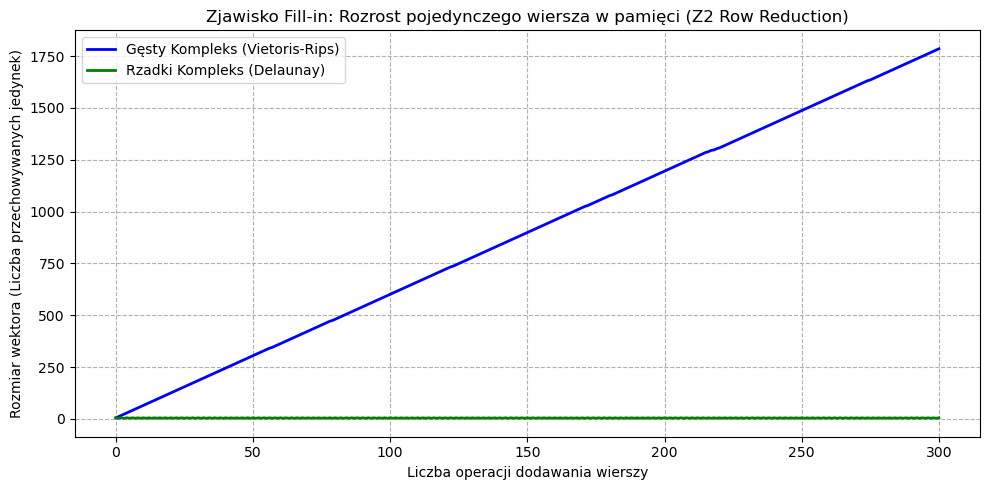

In [10]:
import random
import matplotlib.pyplot as plt

def simulate_pCoh_row_addition(name, is_dense, iterations=300):
    """
    Symuluje wewnętrzną pętlę algorytmu pCoh (Dionysusa) w C++.
    Wiersz macierzy to lista indeksów (tu: zbiór, by łatwo robić XOR).
    """
    # Zaczynamy z bardzo rzadkim, małym kokyklem (np. 5 krawędzi)
    active_cocycle = set(random.sample(range(100000), 5))
    elements_history = [len(active_cocycle)]

    for _ in range(iterations):
        # Przychodzi nowy sympleks z kompleksu i musimy dodać jego wiersz do naszego kokyklu.
        # Nowy wiersz też jest rzadki (np. ma 6 krawędzi brzegowych).
        
        if is_dense:
            # GĘSTY KOMPLEKS (Vietoris-Rips): 
            # W gęstej chmurze nowy sympleks często wprowadza zupełnie nowe, 
            # niepowiązane wcześniej krawędzie. Część wspólna z obecnym kokyklem jest mała.
            new_row = set(random.sample(range(100000), 6))
        else:
            # RZADKI KOMPLEKS (Delaunay / Alpha Shapes):
            # W rzadkiej sieci nowy sympleks zawsze współdzieli większość krawędzi
            # z już istniejącymi, lokalnymi strukturami (silne pokrycie).
            # Symulujemy to, biorąc 4 krawędzie z obecnego kokyklu i tylko 2 nowe.
            overlap = set(list(active_cocycle)[:4]) if len(active_cocycle) >= 4 else set()
            new_row = overlap.union(set(random.sample(range(100000), 2)))

        # DIONYSUS CORE: Dodawanie w Z2 to różnica symetryczna (XOR)
        # 1 + 1 = 0 (usunięcie elementu)
        # 1 + 0 = 1, 0 + 1 = 1 (DODANIE ELEMENTU -> FILL-IN)
        active_cocycle = active_cocycle.symmetric_difference(new_row)
        
        elements_history.append(len(active_cocycle))

    return elements_history

print("="*60)
print(" SYMULACJA ZJAWISKA FILL-IN W Z2 (Mechanika pCoh)")
print("="*60)

# 1. Odpalamy symulację dla struktury RZADKIEJ
history_sparse = simulate_pCoh_row_addition("Delaunay", is_dense=False)
print(f"[Alpha Shapes / Delaunay]")
print(f"  Początkowy rozmiar wektora: {history_sparse[0]} elementów")
print(f"  Końcowy rozmiar wektora:    {history_sparse[-1]} elementów")
print(f"  -> Wniosek: Brak Fill-in. XOR kasuje jedynki (1+1=0).\n")

# 2. Odpalamy symulację dla struktury GĘSTEJ
history_dense = simulate_pCoh_row_addition("Vietoris-Rips", is_dense=True)
print(f"[Vietoris-Rips]")
print(f"  Początkowy rozmiar wektora: {history_dense[0]} elementów")
print(f"  Końcowy rozmiar wektora:    {history_dense[-1]} elementów")
print(f"  -> Wniosek: EKSPLOZJA FILL-IN! XOR dodaje jedynki (1+0=1).\n")

# --- Opcjonalny Wykres ---
plt.figure(figsize=(10, 5))
plt.plot(history_dense, label="Gęsty Kompleks (Vietoris-Rips)", color='blue', linewidth=2)
plt.plot(history_sparse, label="Rzadki Kompleks (Delaunay)", color='green', linewidth=2)
plt.title("Zjawisko Fill-in: Rozrost pojedynczego wiersza w pamięci (Z2 Row Reduction)")
plt.xlabel("Liczba operacji dodawania wierszy")
plt.ylabel("Rozmiar wektora (Liczba przechowywanych jedynek)")
plt.legend()
plt.grid(True, ls="--")
plt.tight_layout()
plt.savefig("fill_in_proof.png")
print("Wygenerowano wykres 'fill_in_proof.png'. Zobacz na własne oczy!")